### Libraries

In [19]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
from scipy import stats

### Load and inspect Dataset

In [7]:
df = pd.read_csv("..\..\..\Data\supply_chain\supply_chain_data.csv")

print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")
print(f"\nDtypes: \n{df.dtypes}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape   : (100, 24)
Columns : ['Product type', 'SKU', 'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Customer demographics', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Inspection results', 'Defect rates', 'Transportation modes', 'Routes', 'Costs']

Dtypes: 
Product type                object
SKU                         object
Price                      float64
Availability                 int64
Number of products sold      int64
Revenue generated          float64
Customer demographics       object
Stock levels                 int64
Lead times                   int64
Order quantities             int64
Shipping times               int64
Shipping carriers           object
Shipping costs             float64
Supplier name               object
Location                    object
Lead time  

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282


### Data Health

In [8]:
print("=== NULL CHECK ===")
print(df.isnull().sum())

print(f"\n=== BASIC COUNTS ===")
print(df.describe())

print(f"\n=== UNIQUE COUNTS ===")
for col in df.columns:
    n = df[col].nunique()
    if n <= 10:
        print(f"    {col}: {n} unique to {df[col].unique().tolist()}")
    else:
        print(f"    {col}: {n} unique values")

=== NULL CHECK ===
Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

=== BASIC COUNTS ===
            Price  Availability  Number of products sold  Revenue generated  \
count  100.000000    100.000000               100.000000         100.000000   
mean    49.462461     48.400000               460.990000        5776.048187   
std     31.16

In [11]:
# === DECODE THE DATASET ===

print("=== PRODUCT TYPES ===")
print(df['Product type'].value_counts())

print(f"\n=== TWO LEAD TIME COLUMNS - are they different? ===")
print(df[['SKU', 'Lead times', 'Lead time', 'Manufacturing lead time']].head(10))
print(f"\nCorrelation between Lead times and Lead time: "
      f"{df['Lead times'].corr(df['Lead time']):.3f}")
print(f"Lead times range    : {df['Lead times'].min()} - {df['Lead times'].max()} days")
print(f"Lead time range     : {df['Lead time'].min()} - {df['Lead time'].max()} days")
print(f"Manufacturing range : {df['Manufacturing lead time'].min()} -"
      f"{df['Manufacturing lead time'].max()} days")

print(f"\n=== DEMAND & STOCK OVERVIEW ===")
print(df[['Number of products sold', 'Stock levels',
          'Order quantities', 'Availability']].describe().round(1))

print(f"\n=== COST OVERVIEW ===")
print(df[['Price', 'Manufacturing costs',
          'Shipping costs', 'Costs']].describe().round(2))

print(f"\n=== DEFECT RATES ===")
print(f"Avg defect rate : {df['Defect rates'].mean():.2%}")
print(f"Max defect rate : {df['Defect rates'].max():.2%}")
print(df['Defect rates'].describe().round(4))

# Quick revenue check
df['calc_revenue'] = df['Price'] * df['Number of products sold']
df['revenue_match'] = (df['calc_revenue'] - df['Revenue generated']).abs()
print(f"\n=== REVENUE SANITY CHECK ===")
print(f"Price x sold matches Revenue generated: "
      f"{(df['revenue_match'] < 1).mean():.0%} of rows")
print(f"(Discrepancy suggests promotions or variable pricing)")

=== PRODUCT TYPES ===
Product type
skincare     40
haircare     34
cosmetics    26
Name: count, dtype: int64

=== TWO LEAD TIME COLUMNS - are they different? ===
    SKU  Lead times  Lead time  Manufacturing lead time
0  SKU0           7         29                       29
1  SKU1          30         23                       30
2  SKU2          10         12                       27
3  SKU3          13         24                       18
4  SKU4           3          5                        3
5  SKU5          27         10                       17
6  SKU6          15         14                       24
7  SKU7          17         22                        1
8  SKU8          10         13                        8
9  SKU9          27         29                       23

Correlation between Lead times and Lead time: -0.003
Lead times range    : 1 - 30 days
Lead time range     : 1 - 30 days
Manufacturing range : 1 -30 days

=== DEMAND & STOCK OVERVIEW ===
       Number of products sold  St

In [12]:
# ================================================================
# PART 1 — DEMAND STATISTICS & DATA PREPARATION
# ================================================================

# True average selling price
df['avg_selling_price'] = df['Revenue generated'] / df['Number of products sold']

# Total replenishment lead time = max of all three lead time components
# This is the conservative planning assumption
df['total_lead_time'] = df[['Lead times','Lead time',
                             'Manufacturing lead time']].max(axis=1)

# Effective units sold after accounting for defects
# Defective units returned = demand signal noise
df['effective_demand'] = (df['Number of products sold'] *
                           (1 - df['Defect rates']))

# Daily demand rate (assume 365-day selling year)
df['daily_demand'] = df['effective_demand'] / 365

# Demand variability — simulate std dev from availability
# High availability = stable demand, Low availability = volatile
# availability 95%+ → cv 0.10, availability <50% → cv 0.35
df['demand_cv'] = 0.35 - (df['Availability'] / 100 * 0.25)
df['demand_std_daily'] = df['daily_demand'] * df['demand_cv']

# Lead time variability (std dev = 20% of total lead time)
df['lead_time_std'] = df['total_lead_time'] * 0.20

print("=== DEMAND STATISTICS ===")
print(df.groupby('Product type')[['daily_demand','demand_cv',
                                   'total_lead_time','effective_demand']]
        .mean().round(2))

print(f"\n=== TOTAL LEAD TIME DISTRIBUTION ===")
print(df['total_lead_time'].describe().round(1))
print(f"\nSample — first 5 SKUs:")
print(df[['SKU','Product type','Number of products sold',
          'effective_demand','daily_demand',
          'total_lead_time']].head().to_string(index=False))

# ================================================================
# PART 2 — SAFETY STOCK CALCULATION
# ================================================================
# Safety stock protects against demand and lead time variability
#
# Formula:
# SS = Z × √(LT × σ_d² + d² × σ_LT²)
#
# Where:
# Z     = service level Z-score
# LT    = average lead time (days)
# σ_d   = std dev of daily demand
# d     = avg daily demand
# σ_LT  = std dev of lead time
# ================================================================

from scipy import stats

SERVICE_LEVELS = {
    'skincare' : 0.95,   # high — customer loyalty sensitive
    'haircare' : 0.90,   # medium — some substitutability
    'cosmetics': 0.85,   # lower — more impulse, less loyalty
}

def calculate_safety_stock(row):
    sl    = SERVICE_LEVELS.get(row['Product type'], 0.90)
    z     = stats.norm.ppf(sl)
    d     = row['daily_demand']
    sigma_d  = row['demand_std_daily']
    lt    = row['total_lead_time']
    sigma_lt = row['lead_time_std']

    # Combined variability formula
    ss = z * np.sqrt(lt * sigma_d**2 + d**2 * sigma_lt**2)
    return round(ss, 1)

df['service_level'] = df['Product type'].map(SERVICE_LEVELS)
df['z_score']       = df['service_level'].apply(stats.norm.ppf)
df['safety_stock']  = df.apply(calculate_safety_stock, axis=1)

print(f"\n=== SAFETY STOCK RESULTS ===")
print(df.groupby('Product type')[['safety_stock','service_level',
                                   'z_score']].mean().round(2))
print(f"\nTop 5 SKUs requiring most safety stock:")
print(df.nlargest(5,'safety_stock')[['SKU','Product type',
      'daily_demand','total_lead_time',
      'safety_stock']].to_string(index=False))

# ================================================================
# PART 3 — REORDER POINT (ROP)
# ================================================================
# ROP = (avg daily demand × total lead time) + safety stock
# "When stock drops to ROP, place a new order"
# ================================================================

df['rop'] = (df['daily_demand'] * df['total_lead_time'] +
             df['safety_stock']).round(1)

print(f"\n=== REORDER POINTS ===")
print(df.groupby('Product type')['rop'].describe().round(1))

print(f"\nSample ROP vs current stock:")
print(df[['SKU','Product type','Stock levels','rop',
          'safety_stock']].head(10).to_string(index=False))

# Flag SKUs below ROP right now
df['below_rop']    = (df['Stock levels'] < df['rop']).astype(int)
df['stockout_risk'] = (df['Stock levels'] < df['safety_stock']).astype(int)

print(f"\nSKUs currently below ROP      : "
      f"{df['below_rop'].sum()} / {len(df)}")
print(f"SKUs at stockout risk          : "
      f"{df['stockout_risk'].sum()} / {len(df)}")

# ================================================================
# PART 4 — ECONOMIC ORDER QUANTITY (EOQ)
# ================================================================
# EOQ = √(2DS / H)
#
# Where:
# D = annual demand (units)
# S = ordering cost per order ($)
# H = holding cost per unit per year ($)
#     = price × holding cost rate (typically 20-25%)
# ================================================================

HOLDING_COST_RATE = 0.25   # 25% of unit cost per year
ORDERING_COST     = 50     # $50 fixed cost per purchase order

df['annual_demand']  = df['effective_demand']
df['holding_cost']   = df['avg_selling_price'] * HOLDING_COST_RATE
df['eoq']            = np.sqrt(
                         (2 * df['annual_demand'] * ORDERING_COST) /
                         df['holding_cost']
                       ).round(0)

# Orders per year at EOQ vs current order quantity
df['orders_per_year_eoq']     = (df['annual_demand'] / df['eoq']).round(1)
df['orders_per_year_current'] = (df['annual_demand'] /
                                  df['Order quantities']).round(1)

# Total cost comparison: ordering cost + holding cost
df['total_cost_eoq'] = (
    (df['annual_demand'] / df['eoq']) * ORDERING_COST +
    (df['eoq'] / 2) * df['holding_cost']
).round(2)

df['total_cost_current'] = (
    (df['annual_demand'] / df['Order quantities']) * ORDERING_COST +
    (df['Order quantities'] / 2) * df['holding_cost']
).round(2)

df['cost_saving'] = (df['total_cost_current'] -
                      df['total_cost_eoq']).round(2)

print(f"\n=== EOQ RESULTS ===")
print(df.groupby('Product type')[['eoq','Order quantities',
                                   'cost_saving']].mean().round(1))

print(f"\nTotal annual cost saving from EOQ: "
      f"${df['cost_saving'].sum():,.0f}")
print(f"Avg cost saving per SKU          : "
      f"${df['cost_saving'].mean():,.0f}")

print(f"\nTop 5 SKUs with highest cost saving:")
print(df.nlargest(5,'cost_saving')[['SKU','Product type',
      'Order quantities','eoq','cost_saving']].to_string(index=False))

=== DEMAND STATISTICS ===
              daily_demand  demand_cv  total_lead_time  effective_demand
Product type                                                            
cosmetics            -1.06       0.22            21.58           -386.53
haircare             -1.38       0.24            25.03           -503.36
skincare             -1.92       0.22            22.85           -701.90

=== TOTAL LEAD TIME DISTRIBUTION ===
count    100.0
mean      23.3
std        5.7
min        5.0
25%       19.0
50%       25.0
75%       28.0
max       30.0
Name: total_lead_time, dtype: float64

Sample — first 5 SKUs:
 SKU Product type  Number of products sold  effective_demand  daily_demand  total_lead_time
SKU0     haircare                      802        620.418891      1.699778               29
SKU1     skincare                      736      -2836.594067     -7.771491               30
SKU2     haircare                        8        -28.644741     -0.078479               27
SKU3     skincare    

In [13]:
# Fix defect rate scale — check what the actual values look like
print("Defect rate sample values:")
print(df['Defect rates'].describe())
print(df['Defect rates'].head(10).tolist())

Defect rate sample values:
count    100.000000
mean       2.277158
std        1.461366
min        0.018608
25%        1.009650
50%        2.141863
75%        3.563995
max        4.939255
Name: Defect rates, dtype: float64
[0.2264103608499251, 4.854068026388706, 4.580592619199229, 4.74664862064775, 3.145579522833002, 2.7791935115711617, 1.0009106193041355, 0.3981771868506506, 2.709862691109961, 3.844614478767585]


In [14]:
# Fix: if defect rates > 1 they're percentages — convert to decimals
df['defect_rate_clean'] = df['Defect rates'].apply(
    lambda x: x / 100 if x > 1 else x
)

print(f"\nBefore fix - Defect rates range: "
      f"{df['Defect rates'].min():.3f} – {df['Defect rates'].max():.3f}")
print(f"After fix  - Defect rates range: "
      f"{df['defect_rate_clean'].min():.3f} – "
      f"{df['defect_rate_clean'].max():.3f}")

# Recalculate effective demand with corrected defect rates
df['effective_demand'] = (df['Number of products sold'] *
                           (1 - df['defect_rate_clean']))
df['daily_demand']     = df['effective_demand'] / 365
df['demand_std_daily'] = df['daily_demand'] * df['demand_cv']

# Verify — all values should now be positive
print(f"\nNegative demand rows after fix: "
      f"{(df['daily_demand'] < 0).sum()}")
print(f"\nDemand stats after fix:")
print(df.groupby('Product type')[['daily_demand',
      'effective_demand']].mean().round(2))


Before fix - Defect rates range: 0.019 – 4.939
After fix  - Defect rates range: 0.010 – 0.965

Negative demand rows after fix: 0

Demand stats after fix:
              daily_demand  effective_demand
Product type                                
cosmetics             0.94            344.63
haircare              0.93            337.69
skincare              1.32            483.14


In [18]:
# ================================================================
# PART 2 — SAFETY STOCK
# ================================================================
SERVICE_LEVELS = {
    'skincare' : 0.95,
    'haircare' : 0.90,
    'cosmetics': 0.85,
}

df['service_level'] = df['Product type'].map(SERVICE_LEVELS)
df['z_score']       = df['service_level'].apply(stats.norm.ppf)
df['lead_time_std'] = df['total_lead_time'] * 0.20

def calculate_safety_stock(row):
    z        = stats.norm.ppf(row['service_level'])
    d        = row['daily_demand']
    sigma_d  = row['demand_std_daily']
    lt       = row['total_lead_time']
    sigma_lt = row['lead_time_std']
    ss       = z * np.sqrt(lt * sigma_d**2 + d**2 * sigma_lt**2)
    return round(max(ss, 0), 1)

df['safety_stock'] = df.apply(calculate_safety_stock, axis=1)

print("=== SAFETY STOCK RESULTS ===")
print(df.groupby('Product type')[['safety_stock','service_level',
                                   'z_score']].mean().round(2))
print(f"\nTop 5 SKUs requiring most safety stock:")
print(df.nlargest(5,'safety_stock')[['SKU','Product type',
      'daily_demand','total_lead_time',
      'safety_stock']].to_string(index=False))

# ================================================================
# PART 3 — REORDER POINT
# ================================================================
df['rop'] = (df['daily_demand'] * df['total_lead_time'] +
             df['safety_stock']).round(1)

df['below_rop']     = (df['Stock levels'] < df['rop']).astype(int)
df['stockout_risk'] = (df['Stock levels'] < df['safety_stock']).astype(int)

print(f"\n=== REORDER POINTS ===")
print(df[['SKU','Product type','Stock levels','rop',
          'safety_stock','below_rop','stockout_risk']]
        .head(10).to_string(index=False))

print(f"\nSKUs currently below ROP    : {df['below_rop'].sum()} / {len(df)}")
print(f"SKUs at stockout risk       : {df['stockout_risk'].sum()} / {len(df)}")

# ================================================================
# PART 4 — EOQ
# ================================================================
HOLDING_COST_RATE = 0.25
ORDERING_COST     = 50

df['annual_demand']  = df['effective_demand']
df['holding_cost']   = df['avg_selling_price'] * HOLDING_COST_RATE
df['eoq']            = np.sqrt(
                         (2 * df['annual_demand'] * ORDERING_COST) /
                          df['holding_cost']
                       ).round(0)

df['total_cost_eoq'] = (
    (df['annual_demand'] / df['eoq']) * ORDERING_COST +
    (df['eoq'] / 2) * df['holding_cost']
).round(2)

df['total_cost_current'] = (
    (df['annual_demand'] / df['Order quantities']) * ORDERING_COST +
    (df['Order quantities'] / 2) * df['holding_cost']
).round(2)

df['cost_saving'] = (df['total_cost_current'] -
                      df['total_cost_eoq']).round(2)

print(f"\n=== EOQ RESULTS ===")
print(df.groupby('Product type')[['eoq','Order quantities',
                                   'cost_saving']].mean().round(1))

print(f"\nTotal annual saving from EOQ : ${df['cost_saving'].sum():,.0f}")
print(f"Avg saving per SKU           : ${df['cost_saving'].mean():,.0f}")

print(f"\nTop 5 SKUs — highest cost saving:")
print(df.nlargest(5,'cost_saving')[['SKU','Product type','Price',
      'Order quantities','eoq','cost_saving']].to_string(index=False))

print(f"\nSKUs where current order qty > EOQ (over-ordering):")
over = df[df['Order quantities'] > df['eoq']]
print(f"  Count : {len(over)} / {len(df)}")
print(f"  Avg excess units per order: "
      f"{(over['Order quantities'] - over['eoq']).mean():.0f}")

# ================================================================
# PART 5 — INVENTORY HEALTH CLASSIFICATION
# ================================================================
def classify_sku(row):
    if row['stockout_risk'] == 1:
        return 'CRITICAL — Stockout risk'
    elif row['below_rop'] == 1:
        return 'WARNING — Below ROP'
    elif row['Stock levels'] > row['rop'] * 2:
        return 'OVERSTOCK'
    else:
        return 'HEALTHY'

df['inventory_status'] = df.apply(classify_sku, axis=1)

print(f"\n=== INVENTORY HEALTH SUMMARY ===")
print(df['inventory_status'].value_counts())

print(f"\nBy product type:")
print(pd.crosstab(df['Product type'],
                  df['inventory_status'],
                  margins=True))

# Working capital tied up in inventory
df['inventory_value'] = df['Stock levels'] * df['avg_selling_price']

print(f"\n=== WORKING CAPITAL ===")
print(df.groupby('Product type')['inventory_value']
        .agg(['sum','mean']).round(0))
print(f"\nTotal inventory value : ${df['inventory_value'].sum():,.0f}")
print(f"Overstock value       : "
      f"${df[df['inventory_status']=='OVERSTOCK']['inventory_value'].sum():,.0f}")
critical = df[df['inventory_status'] == 'CRITICAL — Stockout risk']
print(f"Critical SKU value    : ${critical['inventory_value'].sum():,.0f}")

=== SAFETY STOCK RESULTS ===
              safety_stock  service_level  z_score
Product type                                      
cosmetics             4.45           0.85     1.04
haircare              6.26           0.90     1.28
skincare             10.06           0.95     1.64

Top 5 SKUs requiring most safety stock:
  SKU Product type  daily_demand  total_lead_time  safety_stock
 SKU9     skincare      2.581706               29          25.4
SKU11     skincare      2.574457               28          23.8
SKU98     skincare      2.428627               28          23.0
SKU36     skincare      2.537953               26          22.4
SKU37     skincare      2.569487               24          21.5

=== REORDER POINTS ===
 SKU Product type  Stock levels   rop  safety_stock  below_rop  stockout_risk
SKU0     haircare            58  62.2          12.9          1              0
SKU1     skincare            53  76.6          19.0          1              0
SKU2     haircare             1  

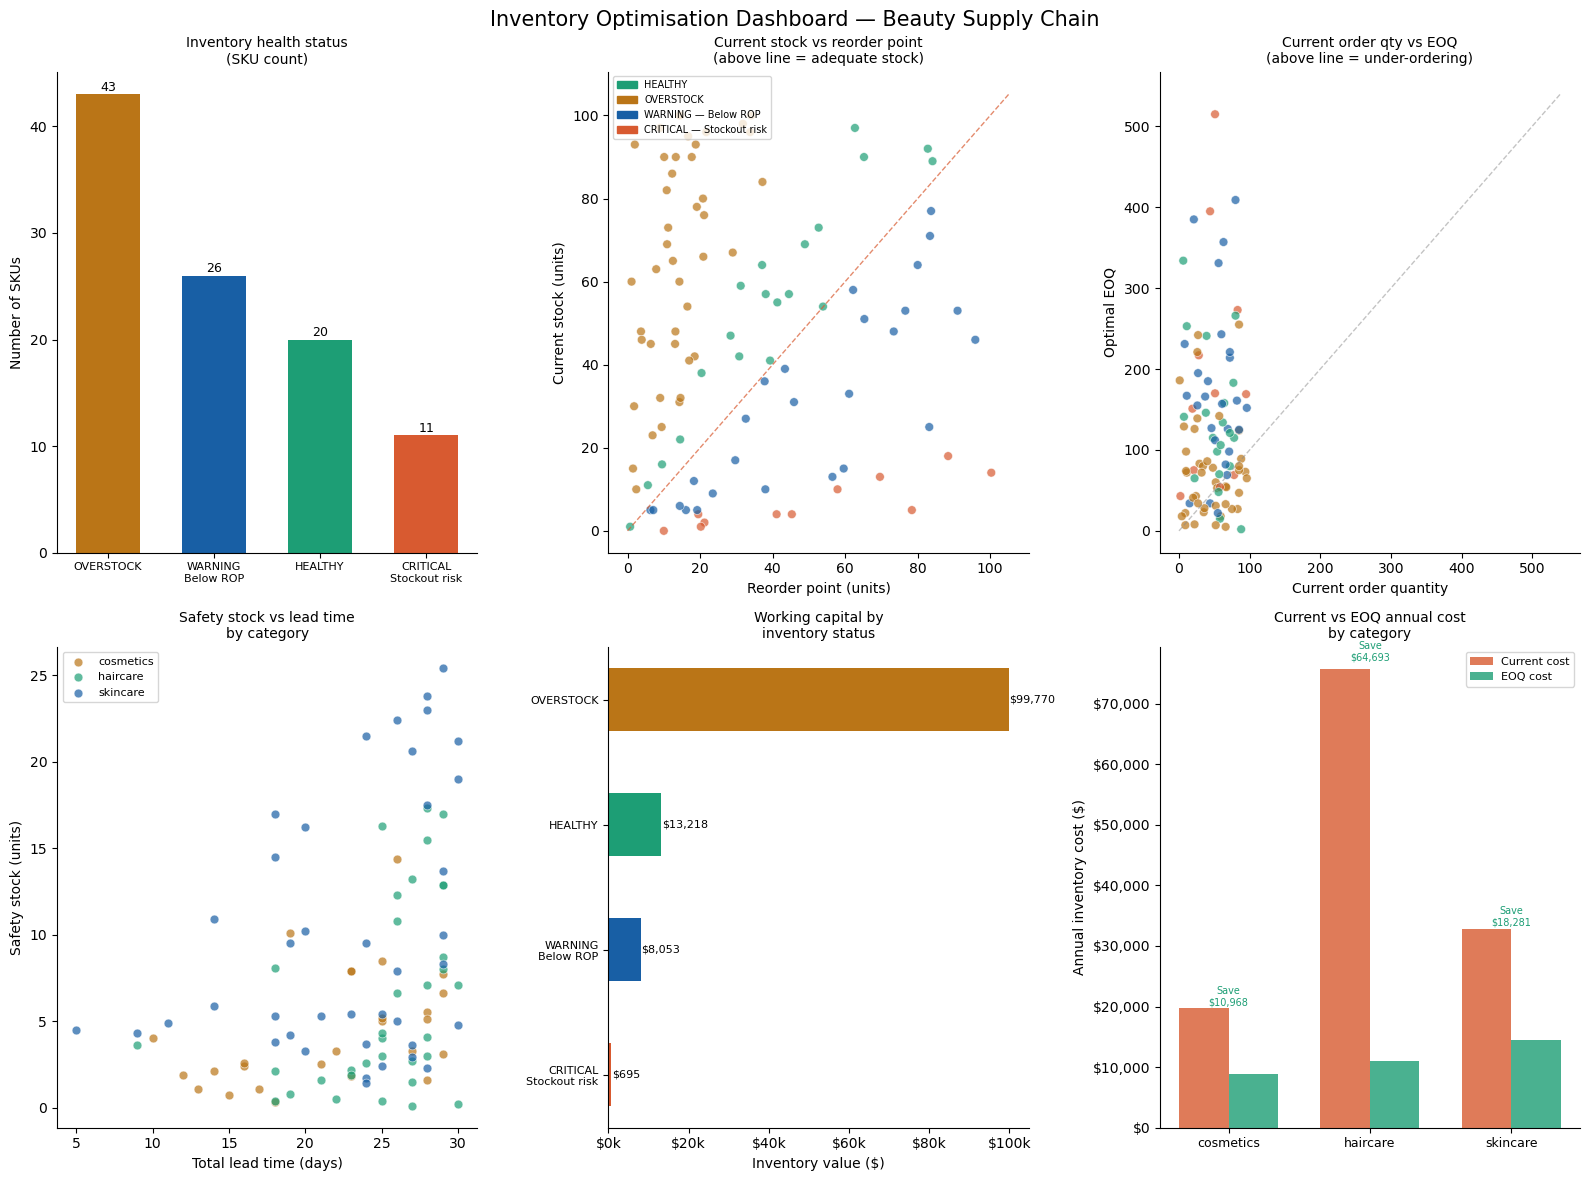

INVENTORY OPTIMISATION SUMMARY

SKU COUNT BY STATUS:
inventory_status
OVERSTOCK                   43
WARNING — Below ROP         26
HEALTHY                     20
CRITICAL — Stockout risk    11

FINANCIAL IMPACT:
  Total inventory value    : $121,736
  Overstock value          : $99,770
  SKUs below ROP           : 37
  SKUs at stockout risk    : 11

EOQ OPTIMISATION:
  Total saving from EOQ    : $93,942
  SKUs over-ordering       : 26 / 100
  SKUs under-ordering      : 74 / 100

TOP 3 ACTIONS:
  1. Release $99,770 tied up in 43 overstocked SKUs
  2. Place immediate orders for 37 SKUs below reorder point
  3. Switch to EOQ ordering to save $93,942/year in inventory costs


In [20]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Inventory Optimisation Dashboard — Beauty Supply Chain',
             fontsize=15, fontweight='normal', y=0.98)

# === CHART 1: Inventory health status (top left) ===
ax1 = fig.add_subplot(2, 3, 1)
status_counts = df['inventory_status'].value_counts()
colors_status = {
    'HEALTHY'              : '#1D9E75',
    'OVERSTOCK'            : '#BA7517',
    'WARNING — Below ROP'  : '#185FA5',
    'CRITICAL — Stockout risk': '#D85A30',
}
bar_colors = [colors_status.get(s, '#888') for s in status_counts.index]
bars = ax1.bar(range(len(status_counts)), status_counts.values,
               color=bar_colors, width=0.6)
ax1.set_xticks(range(len(status_counts)))
ax1.set_xticklabels([s.replace(' — ', '\n') for s in status_counts.index],
                     fontsize=8)
ax1.set_title('Inventory health status\n(SKU count)', fontsize=10)
ax1.set_ylabel('Number of SKUs')
for bar, val in zip(bars, status_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# === CHART 2: Current stock vs ROP scatter (top middle) ===
ax2 = fig.add_subplot(2, 3, 2)
status_colors = df['inventory_status'].map(colors_status).fillna('#888')
ax2.scatter(df['rop'], df['Stock levels'],
            c=status_colors, alpha=0.7, s=40, edgecolors='white', linewidth=0.5)
max_val = max(df['rop'].max(), df['Stock levels'].max()) * 1.05
ax2.plot([0, max_val], [0, max_val], color='#D85A30',
         linewidth=1, linestyle='--', alpha=0.7)
ax2.set_xlabel('Reorder point (units)')
ax2.set_ylabel('Current stock (units)')
ax2.set_title('Current stock vs reorder point\n(above line = adequate stock)',
              fontsize=10)
legend_patches = [mpatches.Patch(color=v, label=k)
                  for k, v in colors_status.items()]
ax2.legend(handles=legend_patches, fontsize=7, loc='upper left')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# === CHART 3: EOQ vs current order quantity (top right) ===
ax3 = fig.add_subplot(2, 3, 3)
x = np.arange(len(df))
width = 0.4
ax3.scatter(df['Order quantities'], df['eoq'],
            c=status_colors, alpha=0.7, s=40,
            edgecolors='white', linewidth=0.5)
max_qty = max(df['Order quantities'].max(), df['eoq'].max()) * 1.05
ax3.plot([0, max_qty], [0, max_qty], color='#888',
         linewidth=1, linestyle='--', alpha=0.5)
ax3.set_xlabel('Current order quantity')
ax3.set_ylabel('Optimal EOQ')
ax3.set_title('Current order qty vs EOQ\n(above line = under-ordering)',
              fontsize=10)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# === CHART 4: Safety stock by category (bottom left) ===
ax4 = fig.add_subplot(2, 3, 4)
cat_colors = {'skincare':'#185FA5','haircare':'#1D9E75','cosmetics':'#BA7517'}
for cat, grp in df.groupby('Product type'):
    ax4.scatter(grp['total_lead_time'], grp['safety_stock'],
                c=cat_colors[cat], alpha=0.7, s=40,
                label=cat, edgecolors='white', linewidth=0.5)
ax4.set_xlabel('Total lead time (days)')
ax4.set_ylabel('Safety stock (units)')
ax4.set_title('Safety stock vs lead time\nby category', fontsize=10)
ax4.legend(fontsize=8)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

# === CHART 5: Working capital by status (bottom middle) ===
ax5 = fig.add_subplot(2, 3, 5)
wc = df.groupby('inventory_status')['inventory_value'].sum().sort_values()
bar_colors_wc = [colors_status.get(s, '#888') for s in wc.index]
bars5 = ax5.barh(range(len(wc)), wc.values, color=bar_colors_wc, height=0.5)
ax5.set_yticks(range(len(wc)))
ax5.set_yticklabels([s.replace(' — ', '\n') for s in wc.index], fontsize=8)
ax5.set_xlabel('Inventory value ($)')
ax5.set_title('Working capital by\ninventory status', fontsize=10)
ax5.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
for bar, val in zip(bars5, wc.values):
    ax5.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
             f'${val:,.0f}', va='center', fontsize=8)
ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)

# === CHART 6: Cost saving from EOQ (bottom right) ===
ax6 = fig.add_subplot(2, 3, 6)
cost_by_cat = df.groupby('Product type').agg(
    current_cost=('total_cost_current','sum'),
    eoq_cost    =('total_cost_eoq',    'sum'),
    saving      =('cost_saving',       'sum')
).round(0)
x6   = np.arange(len(cost_by_cat))
w6   = 0.35
b1   = ax6.bar(x6 - w6/2, cost_by_cat['current_cost'],
               w6, label='Current cost', color='#D85A30', alpha=0.8)
b2   = ax6.bar(x6 + w6/2, cost_by_cat['eoq_cost'],
               w6, label='EOQ cost', color='#1D9E75', alpha=0.8)
ax6.set_xticks(x6)
ax6.set_xticklabels(cost_by_cat.index, fontsize=9)
ax6.set_ylabel('Annual inventory cost ($)')
ax6.set_title('Current vs EOQ annual cost\nby category', fontsize=10)
ax6.legend(fontsize=8)
ax6.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, (_, row) in enumerate(cost_by_cat.iterrows()):
    ax6.text(i, max(row['current_cost'], row['eoq_cost']) * 1.02,
             f'Save\n${row["saving"]:,.0f}',
             ha='center', fontsize=7, color='#1D9E75')
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('inventory_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# === FINAL SUMMARY ===
print("=" * 60)
print("INVENTORY OPTIMISATION SUMMARY")
print("=" * 60)
print(f"\nSKU COUNT BY STATUS:")
print(df['inventory_status'].value_counts().to_string())
print(f"\nFINANCIAL IMPACT:")
print(f"  Total inventory value    : ${df['inventory_value'].sum():,.0f}")
print(f"  Overstock value          : "
      f"${df[df['inventory_status']=='OVERSTOCK']['inventory_value'].sum():,.0f}")
print(f"  SKUs below ROP           : {df['below_rop'].sum()}")
print(f"  SKUs at stockout risk    : {df['stockout_risk'].sum()}")
print(f"\nEOQ OPTIMISATION:")
print(f"  Total saving from EOQ    : ${df['cost_saving'].sum():,.0f}")
print(f"  SKUs over-ordering       : "
      f"{(df['Order quantities'] > df['eoq']).sum()} / {len(df)}")
print(f"  SKUs under-ordering      : "
      f"{(df['Order quantities'] < df['eoq']).sum()} / {len(df)}")
print(f"\nTOP 3 ACTIONS:")
print(f"  1. Release ${df[df['inventory_status']=='OVERSTOCK']['inventory_value'].sum():,.0f} "
      f"tied up in {(df['inventory_status']=='OVERSTOCK').sum()} overstocked SKUs")
print(f"  2. Place immediate orders for "
      f"{df['below_rop'].sum()} SKUs below reorder point")
print(f"  3. Switch to EOQ ordering to save "
      f"${df['cost_saving'].sum():,.0f}/year in inventory costs")